# Hotel Booking Cancellation Prediction
## Decision Tree → Random Forest → Gradient Boosting → XGBoost → LightGBM → CatBoost

**Goal:** predict `is_canceled` from information available when a reservation is made.

We compare six tree-based classifiers, evaluate them with Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC, tune them, analyze errors and save the best model.

### Core mathematics
- Entropy: $H(S)=-\sum_k p_k\log_2 p_k$
- Information Gain: $IG=H(S)-\sum_j\frac{|S_j|}{|S|}H(S_j)$
- Random Forest: $\hat y=\operatorname{mode}(T_1(x),...,T_B(x))$
- Boosting: $F_m(x)=F_{m-1}(x)+\eta h_m(x)$
- Logistic probability used by boosting classifiers: $p=\sigma(F(x))=1/(1+e^{-F(x)})$

Import Modules

In [13]:
import time, warnings, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             precision_recall_curve)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load the Kaggle dataset

In [14]:
DATA_PATH = Path("./data/hotel_bookings.csv")
if not DATA_PATH.exists():
        raise FileNotFoundError("Upload the Hotel Booking Demand dataset to Kaggle first.")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Data understanding

In [15]:
df.info()
display(df.describe(include="all").T)
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(15))
print("Duplicate rows:", df.duplicated().sum())
print("Target distribution:")
display(df["is_canceled"].value_counts(normalize=True).rename("proportion"))

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0



Missing values:


company                      112593
agent                         16340
country                         488
children                          4
arrival_date_month                0
arrival_date_week_number          0
hotel                             0
is_canceled                       0
stays_in_weekend_nights           0
arrival_date_day_of_month         0
adults                            0
stays_in_week_nights              0
babies                            0
meal                              0
lead_time                         0
dtype: int64

Duplicate rows: 31994
Target distribution:


is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

## 3. Cleaning and exploratory analysis

We remove exact duplicates. Missing `children`, `country`, `agent`, and `company` are handled later by model-specific preprocessing; this avoids accidentally using information from the test set.

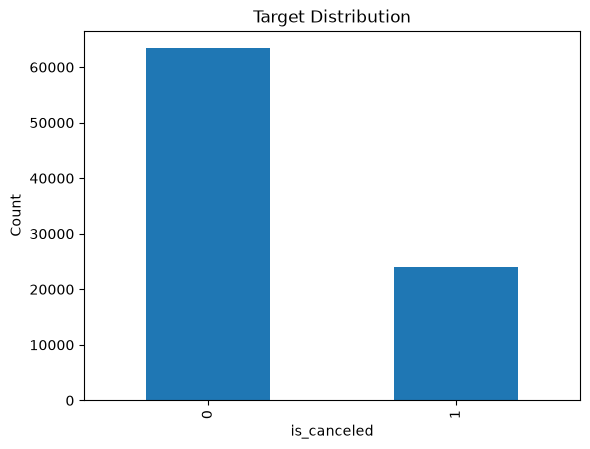

,cancellation_rate
hotel,
City Hotel,0.300386
Resort Hotel,0.234809


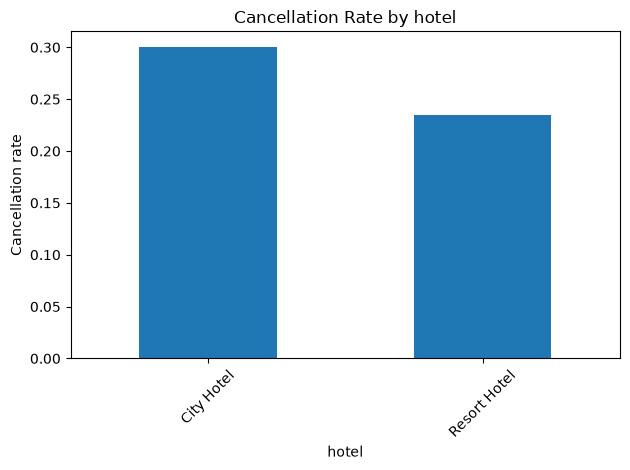

,cancellation_rate
market_segment,
Undefined,1.000000
Online TA,0.353462
Groups,0.270134
Aviation,0.198238
Offline TA/TO,0.148535
Direct,0.147154
Complementary,0.125356
Corporate,0.121083


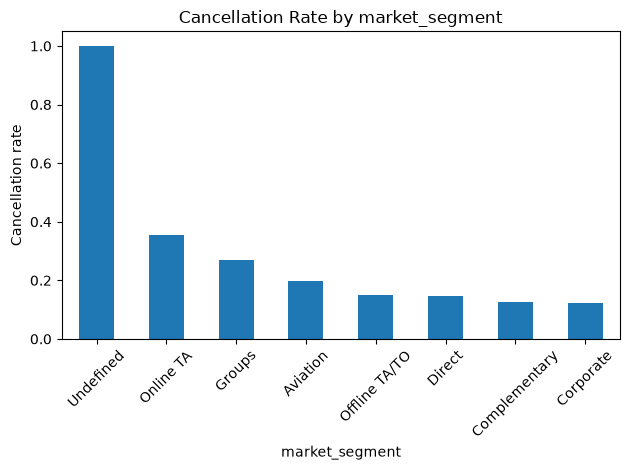

,cancellation_rate
deposit_type,
Non Refund,0.947013
No Deposit,0.266849
Refundable,0.242991


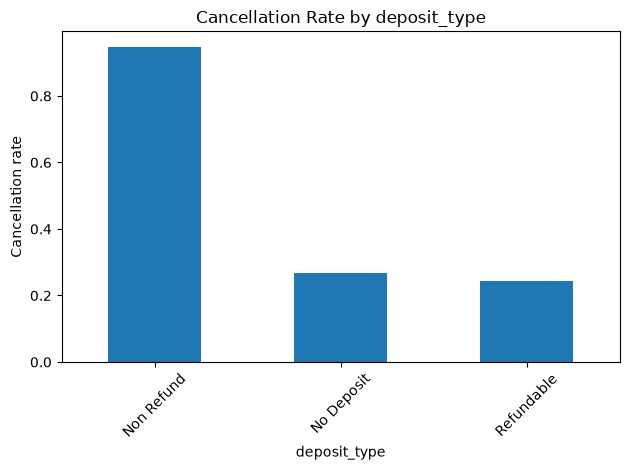

In [16]:
df = df.drop_duplicates().copy()

fig, ax = plt.subplots()
df["is_canceled"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("is_canceled")
ax.set_ylabel("Count")
ax.set_title("Target Distribution")
plt.show()

for col in ["hotel", "market_segment", "deposit_type"]:
    rates = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False)
    display(rates.to_frame("cancellation_rate"))
    rates.plot(kind="bar", title=f"Cancellation Rate by {col}")
    plt.ylabel("Cancellation rate"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 4. Feature engineering

We create features that summarize reservation behavior while avoiding post-booking leakage. For a realistic prediction-at-booking task, we exclude `reservation_status`, `reservation_status_date`, `assigned_room_type`, and `booking_changes` because they can contain information that occurs after the original booking decision.

In [18]:
def engineer_features(data):
    data = data.copy()
    data["total_nights"] = data["stays_in_weekend_nights"] + data["stays_in_week_nights"]
    data["total_guests"] = data["adults"] + data["children"].fillna(0) + data["babies"]
    data["has_children"] = (data["children"].fillna(0) > 0).astype(int)
    data["has_babies"] = (data["babies"] > 0).astype(int)
    data["has_previous_cancellations"] = (data["previous_cancellations"] > 0).astype(int)
    data["adr_per_guest"] = data["adr"] / data["total_guests"].replace(0, np.nan)
    return data

df_model = engineer_features(df)
TARGET = "is_canceled"
DROP_COLUMNS = [TARGET, "reservation_status", "reservation_status_date",
                "assigned_room_type", "booking_changes"]
X = df_model.drop(columns=DROP_COLUMNS)
y = df_model[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(69916, 33) (17480, 33)


## 5. Preprocessing for sklearn, XGBoost and LightGBM

Categorical columns are one-hot encoded. Numeric columns use median imputation. `agent` and `company` are retained as categorical variables here; if memory becomes an issue on Kaggle, they can be removed from the one-hot models while remaining available to CatBoost.

In [19]:
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numerical_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print("Encoded shape:", X_train_enc.shape)

Encoded shape: (69916, 243)
